# Migration analysis 

This notebook shows migration analysis of 2022 Stats SA data and builds on the previous matrix modelling methods (matrix multiplication and a Markov Chain) explored in the notebook ToyModel_age_SA2022.ipynb.

We apply the demographic balancing equation and consider net migration as a residual:
$$\text{current population} = \text{previous popualtion} + \text{births} - \text{deaths}
 + \text{net migration} $$

For existing cohorts corresponding to ages 00-04 to 75-79 at time $t$, that is
$$ N_{i+1}(t+1)=N_i(t)-D_i(t)+M_i(t) $$

For the newest cohort at time $t+1$ (ie all the new borns in the latest time period), we have:
$$ N_0(t+1) = B(t) - D_0(t)+M_0(t)$$

The surviving members of the 80+ age group are combined with the surving member of the 75-79 age group. 

Due to how the data is bucketed, over a 5 year interval ($t$ to $t+5$) a population cohort ages one age group (from $i$ to $i+1$). However, the live birth and mortality rates are reported annually, so we use linear interpolation to estimate the population vectors $\mathbf{n}(t+k)$, $k\in\{1,2,3,4\}$ for intermediate years. 

Using linear interpolation, for each cohort $i$ the annual population is given as
$$ N_{i}(t+k)= N_i(t) + \frac{k}{5}[N_i(t+5)-N_i(t)]$$

and rearranging the balance equation gives: 
$$ M_i(t)= N_{i+1}(t+1) - N_i(t)+D_i(t)$$

**Matrix Multiplication Model**

Previously for population prediction, we used a Leslie matrix projection model such that $\mathbf{n}(t+5)=\mathbf{An}(t)$ represents population growth with no migration. To consider migration, we add a net migration vector $m$ to form an open system:
$$ \mathbf{n}(t+5)=\mathbf{An}(t)+\mathbf{m}(t)$$


<!-- 5. Method B: Integrating Migration into the Absorbing Markov Chain ModelIn your current absorbing Markov chain, individuals move through living states (matrix $\mathbf{U}$) until absorption by death. Net migration represents an external injection or extraction of individuals:Expected Population Structure: The expected population vector under the Markov framework incorporates the fundamental matrix $\mathbf{N} = (\mathbf{I} - \mathbf{U})^{-1}$.Open System Formulation: Migration can be modeled as an open Leontief-style demographic system where the net migration vector acts as an exogenous demand or supply vector. The total population vector required to sustain or match the observed changes is calculated, and individual stochastic variance bounds ($\pm 1.96 \sqrt{\mathbf{n}}$) can be projected forward alongside the migration shifts. -->

### Data:

* We use the 2022 Census data for the initial population vector $\mathbf{n}_0$,
* the Recorded Live Births (2022) report from Stats SA and (link is down 18/05 https://www.statssa.gov.za/publications/P0305/P03052022.pdf)
* the Mortality and causes of death in South Africa: Findings from death notification (2022) report from Stats SA (https://www.statssa.gov.za/publications/P03093/P030932022.pdf).

#### Data Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# import files, 
# clean: remove 'Total' ROWS, ensure all values are numeric and do not contain ","

file_path = 'Data/BirthDeathPop_2022.xlsx'

births_df = pd.read_excel(file_path, sheet_name=0)   
deaths_df  = pd.read_excel(file_path, sheet_name=1)  
pop_df = pd.read_excel(file_path, sheet_name=2)

def clean_sheet_by_index(df):
    # Filter out total rows 
    df = df[~df.iloc[:, 0].astype(str).str.contains('Total|total', na=False)].copy()

    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
    return df.reset_index(drop=True)

births_df = clean_sheet_by_index(births_df)
deaths_df = clean_sheet_by_index(deaths_df)
pop_df = clean_sheet_by_index(pop_df)

In [3]:
births_df.head()

,Mother's Age,Number of Live Births,Percentage (%)
0,00–04,0,0.0
1,05–09,0,0.0
2,10–14,3598,0.4
3,15–19,101569,11.1
4,20–24,203766,22.3


In [4]:
deaths_df.head()

,Age Group,Number of Deaths,Percentage (%)
0,00–04,44785,8.1
1,05–09,4286,0.8
2,10–14,4524,0.8
3,15–19,10723,1.9
4,20–24,18349,3.3


In [5]:
pop_df.head()

,Sex,Male,Female,Total
0,00–04,2918292,2915222,5833515
1,05–09,2561963,2547141,5109104
2,10–14,2713448,2690676,5404124
3,15–19,2504677,2470633,4975309
4,20–24,2670986,2638753,5309738


In [6]:
# pull relevant values into birth, death and population vectors

# births - need to pad the upper ages with 0s
# we ignore the 242 births where the mother's age is unspecified or outside of 10-55 range

birth_counts = births_df.iloc[:,1].values
num_valid_groups = min(len(birth_counts), 11) 
births = np.zeros(17)
births[:num_valid_groups] = birth_counts[:num_valid_groups]

# deaths
deaths = deaths_df.iloc[:, 1].values

# population count
pop_male = pop_df.iloc[:, 1].values
pop_female = pop_df.iloc[:, 2].values
n_t = pop_df.iloc[:, 3].values

print(f"Births vector shape: {births.shape}")
print(f"Deaths vector shape: {deaths.shape}")
print(f"Population vector (Total) shape: {n_t.shape}")

Births vector shape: (17,)
Deaths vector shape: (17,)
Population vector (Total) shape: (17,)


#### Set up of Leslie matrix matrix multiplication model

In [23]:
# Find annual F and P
# n_t is total population vector from 2022 Census

# Calculate fertility rates F_i
F = (births / pop_female) *5 ### changed F to only female population

# Caluclate survival probabilities P_i
# we need i-1 elements as P_i goes along thw subdiagonal
P_annual = ((n_t - deaths) / n_t)
P_adjusted = (P_annual ** 5)
P = P_adjusted[:-1]

for i in range(17):
    f_val = F[i]
    p_val = P[i] if i < 16 else 0.0
    print(f"Age Group {i+1}: F = {f_val:.4f}, P = {p_val:.4f}")

Age Group 1: F = 0.0000, P = 0.9622
Age Group 2: F = 0.0000, P = 0.9958
Age Group 3: F = 0.0067, P = 0.9958
Age Group 4: F = 0.2056, P = 0.9893
Age Group 5: F = 0.3861, P = 0.9828
Age Group 6: F = 0.3994, P = 0.9784
Age Group 7: F = 0.3615, P = 0.9687
Age Group 8: F = 0.2425, P = 0.9597
Age Group 9: F = 0.0878, P = 0.9491
Age Group 10: F = 0.0077, P = 0.9375
Age Group 11: F = 0.0004, P = 0.9221
Age Group 12: F = 0.0000, P = 0.9109
Age Group 13: F = 0.0000, P = 0.8909
Age Group 14: F = 0.0000, P = 0.8714
Age Group 15: F = 0.0000, P = 0.8340
Age Group 16: F = 0.0000, P = 0.8065
Age Group 17: F = 0.0000, P = 0.0000


In [24]:
# Construct Leslie matrix A
A = np.zeros((17, 17))

A[0, :] = F #fertility on top row
A += np.diag(P, k=-1) # survival probs in sub diagonal

# use A and n_t to predict population in 2027 (n_{t+1})

n_2027 = A.dot(n_t)

age_groups = [
    "00–04", "05–09", "10–14", "15–19", "20–24", "25–29", "30–34", "35–39",
    "40–44", "45–49", "50–54", "55–59", "60–64", "65–69", "70–74", "75–79", "80+"]

print("Projected South African Population for 2027 per Age Group:")
print("-" * 45)

# Loop through each age class and print the count formatted with commas
for group, count in zip(age_groups, n_2027):
    print(f"Age Group {group}: {int(round(count)):,}")

print("-" * 45)

# Calculate and print the overall total population count
total_pop_2027 = np.sum(n_2027)
print(f"Total Projected Population (2027): {int(round(total_pop_2027)):,}")

Projected South African Population for 2027 per Age Group:
---------------------------------------------
Age Group 00–04: 9,080,792
Age Group 05–09: 5,613,002
Age Group 10–14: 5,087,710
Age Group 15–19: 5,381,542
Age Group 20–24: 4,921,925
Age Group 25–29: 5,218,625
Age Group 30–34: 5,609,496
Age Group 35–39: 5,417,742
Age Group 40–44: 5,012,314
Age Group 45–49: 3,972,127
Age Group 50–54: 3,087,773
Age Group 55–59: 2,553,559
Age Group 60–64: 2,274,105
Age Group 65–69: 1,867,119
Age Group 70–74: 1,393,889
Age Group 75–79: 872,410
Age Group 80+: 525,850
---------------------------------------------
Total Projected Population (2027): 67,889,981


#### Linear interpolatino to find migration for 2022, 2023, 2024, 2025, 2026 and 2027

In [29]:
# linearly interpolate intermediate annual populations between 2022-2027
pop_interpolation = np.zeros((17, 6))
female_interpolation = np.zeros((17, 6))

pop_female_2027 = n_2027 * (pop_female / n_t)

for i in range(17):
    pop_interpolation[i, :] = np.linspace(n_t[i], n_2027[i], 6)
    female_interpolation[i, :] = np.linspace(pop_female[i], pop_female_2027[i], 6)

# Track annual projections
annual_projections = {}
annual_projections[2022] = n_t.copy()

# get births and deaths by 
cohort_deaths = np.zeros(17)
cohort_births = 0.0

# Calculate vital events annually using the interpolated mid-interval population weights
for k in range(5):
    current_year = 2022 + k
    next_year = current_year + 1
    
    current_pop_year = pop_interpolation[:, k]
    current_female_year = female_interpolation[:, k]
    
    # Calculate annual deaths for this specific year based on 2022 rates
    annual_death_rate = deaths / n_t  
    simulated_annual_deaths = current_pop_year * annual_death_rate
    
    # Tlinear distribution of vital events 
    for i in range(16):
        # A cohort aging from group i to i+1 spends time distributed across both brackets
        cohort_deaths[i] += simulated_annual_deaths[i] * 0.5 + simulated_annual_deaths[i+1] * 0.5
    # The 80+ group accumulates ongoing deaths from both the 75-79 and 80+ baseline classes
    cohort_deaths[16] += simulated_annual_deaths[16]
    
    # Track annual births (contributing to the 00-04 cohort in 2027)
    annual_fertility_rate = births / pop_female
    simulated_annual_births = np.sum(current_female_year * annual_fertility_rate)
    cohort_births += simulated_annual_births

    annual_projections[next_year] = pop_interpolation[:, k+1]

print("Annual Total Population Projections:")
print("-" * 65)
for year, pop_vector in annual_projections.items():
    print(f"Year {year} total pop: {int(round(np.sum(pop_vector))):,}")
print("-" * 65)

Annual Total Population Projections:
-----------------------------------------------------------------
Year 2022 total pop: 62,027,500
Year 2023 total pop: 63,199,996
Year 2024 total pop: 64,372,492
Year 2025 total pop: 65,544,988
Year 2026 total pop: 66,717,484
Year 2027 total pop: 67,889,981
-----------------------------------------------------------------


In [32]:
intervals = ["2022–2023", "2023–2024", "2024–2025", "2025–2026", "2026–2027"]
age_groups_with_total = list(age_groups) + ["TOTAL"]
df_annual_mig = pd.DataFrame()
df_annual_mig["Age Group"] = age_groups_with_total

# Dictionary to hold arrays of annual net migration
annual_migration_results = {interval: np.zeros(17) for interval in intervals}

# Calculate annual death rates from baseline data
annual_death_rate = deaths / n_t

# --- CALCULATE MIGRATION FOR EACH INDIVIDUAL YEAR ---
for k in range(5):
    interval_label = intervals[k]
    
    # Grab population states for year t and year t+1 from your linear interpolation matrix
    N_t = pop_interpolation[:, k]
    N_t1 = pop_interpolation[:, k+1]
    current_female_year = female_interpolation[:, k]
    
    # 1. Calculate the annual deaths for this specific year
    simulated_annual_deaths = N_t * annual_death_rate
    cohort_deaths_this_year = np.zeros(17)
    for i in range(16):
        cohort_deaths_this_year[i] = simulated_annual_deaths[i] * 0.5 + simulated_annual_deaths[i+1] * 0.5
    cohort_deaths_this_year[16] = simulated_annual_deaths[16]
    
    # 2. Calculate annual births for this specific year
    annual_fertility_rate = births / pop_female
    simulated_annual_births = np.sum(current_female_year * annual_fertility_rate)
    
    # 3. Apply the balancing equation to find M_i(t)
    # Newborn Group (00–04): Initial population is births
    deaths_to_newborns = cohort_deaths_this_year[0] * 0.5
    annual_migration_results[interval_label][0] = N_t1[0] - (simulated_annual_births - deaths_to_newborns)
    
    # Standard advancing cohorts (Group i moves to Group i+1)
    for i in range(16):
        annual_migration_results[interval_label][i+1] = N_t1[i+1] - N_t[i] + cohort_deaths_this_year[i]
        
    # Open-ended 80+ group adjustments
    annual_migration_results[interval_label][16] = N_t1[16] - (N_t[15] + N_t[16]) + cohort_deaths_this_year[16]

# --- FORMAT AND APPEND VALUES TO THE DISPLAY DATAFRAME ---
for interval_label in intervals:
    raw_counts = annual_migration_results[interval_label]
    
    # Map numbers to strings with standard balancing signs (+/-)
    formatted_strings = [f"{int(round(x)):+,}" if int(round(x)) != 0 else "0" for x in raw_counts]
    
    # Append the sum total to the bottom row of the list
    total_mig_year = int(round(np.sum(raw_counts)))
    formatted_strings.append(f"{total_mig_year:+,}")
    
    df_annual_mig[interval_label] = formatted_strings

print("\nAnnual Net Migration Matrix Breakdown (2022–2027):")
print("=" * 110)
print(df_annual_mig.to_string(index=False))
print("=" * 110)


Annual Net Migration Matrix Breakdown (2022–2027):
Age Group  2022–2023  2023–2024  2024–2025  2025–2026  2026–2027
    00–04 +5,583,494 +6,237,108 +6,890,722 +7,544,336 +8,197,951
    05–09   -599,096 -1,145,236 -1,691,377 -2,237,518 -2,783,658
    10–14   +236,142    +72,096    -91,951   -255,998   -420,044
    15–19   -339,945   -195,354    -50,764    +93,826   +238,417
    20–24   +271,402   +112,547    -46,309   -205,165   -364,021
    25–29   +342,235   +316,517   +290,799   +265,080   +239,362
    30–34   -106,867       -823   +105,221   +211,265   +317,309
    35–39   -292,085   -256,221   -220,358   -184,494   -148,631
    40–44   -828,831   -701,421   -574,010   -446,599   -319,189
    45–49   -713,121   -741,086   -769,052   -797,018   -824,984
    50–54   -417,275   -487,889   -558,503   -629,117   -699,732
    55–59   -215,931   -267,619   -319,306   -370,994   -422,681
    60–64   -318,103   -293,324   -268,545   -243,765   -218,986
    65–69   -396,857   -377,921   -358

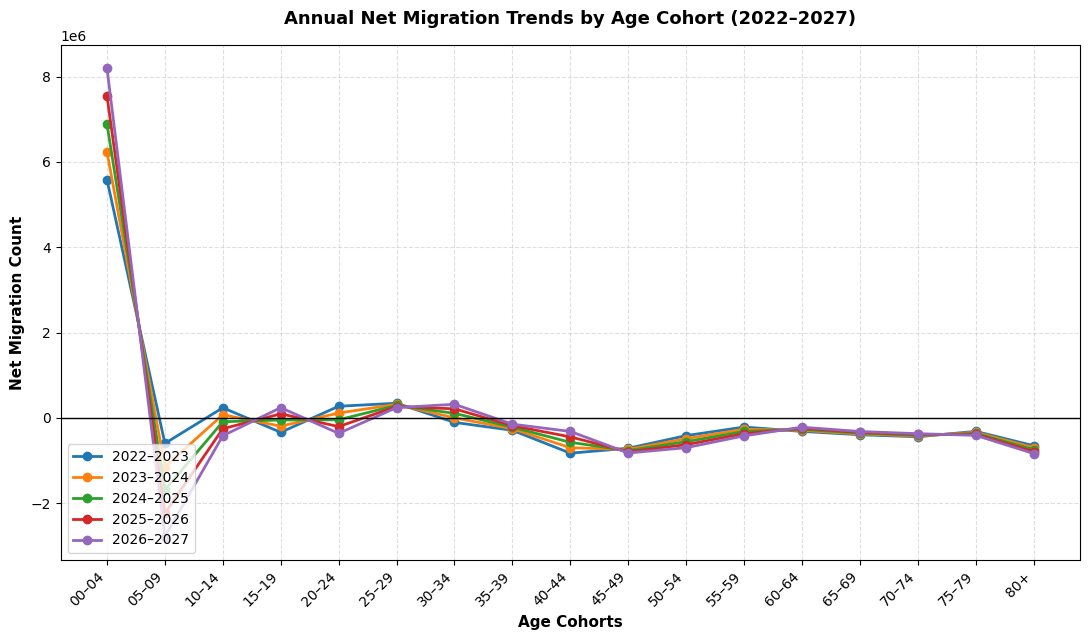

In [36]:
plt.figure(figsize=(11, 6.5))

# Plot each annual interval column as its own line (excluding the 'TOTAL' row)
for interval in intervals:
    y_values = [int(x.replace(',', '')) for x in df_annual_mig.loc[df_annual_mig["Age Group"] != "TOTAL", interval]]
    plt.plot(age_groups, y_values, marker='o', linewidth=2, label=interval)

plt.title('Annual Net Migration Trends (2022 baseline)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Age Cohorts', fontsize=11, fontweight='bold')
plt.ylabel('Net Migration Count', fontsize=11, fontweight='bold')

plt.axhline(0, color='black', linewidth=1, linestyle='-')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=10, loc='lower left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('annual_migration_lines.png', dpi=300)
plt.show()

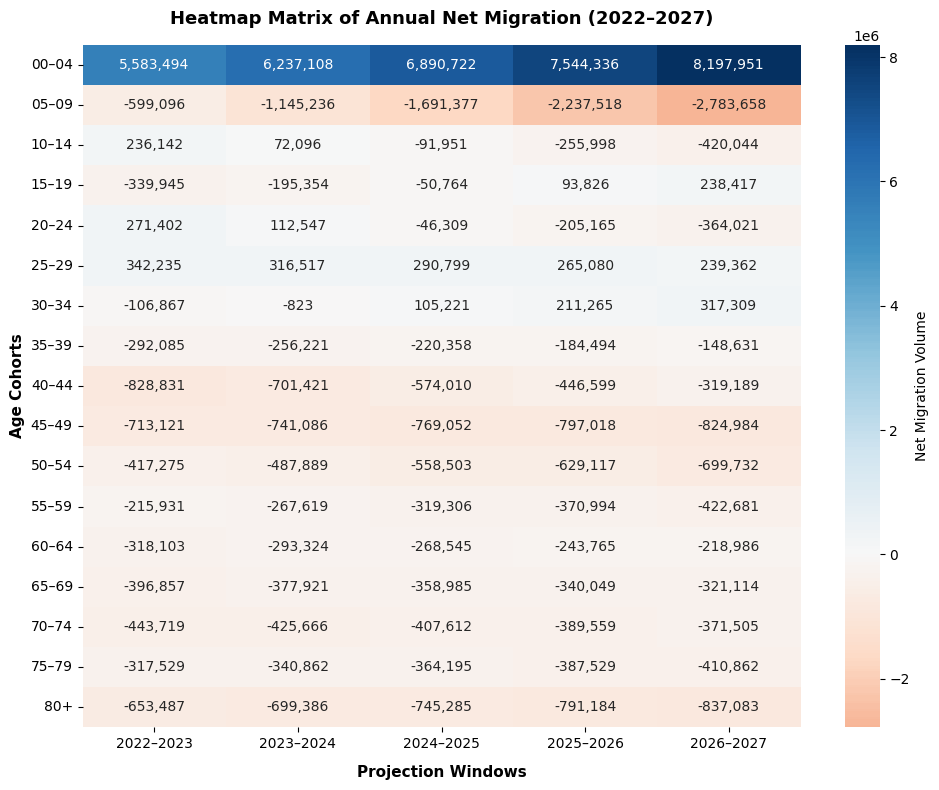

In [37]:
import seaborn as sns
heatmap_data = []
for interval in intervals:
    # Uses "Age Group" to cleanly separate the core metrics from the totals row
    column_numeric = [int(x.replace(',', '')) for x in df_annual_mig.loc[df_annual_mig["Age Group"] != "TOTAL", interval]]
    heatmap_data.append(column_numeric)

# Transpose so Age Groups map to the y-axis and Years map to the x-axis
heatmap_matrix = np.array(heatmap_data).T

plt.figure(figsize=(10, 8))

# Diverging color layout sets zero as a clean off-white background baseline
sns.heatmap(
    heatmap_matrix, 
    annot=True, 
    fmt=",d", 
    cmap="RdBu", 
    center=0,
    xticklabels=intervals, 
    yticklabels=age_groups,
    cbar_kws={'label': 'Net Migration Volume'}
)

plt.title('Heatmap Matrix of Annual Net Migration (2022–2027)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Projection Windows', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Age Cohorts', fontsize=11, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('annual_migration_heatmap.png', dpi=300)
plt.show()

In [39]:
intervals = ["2022–2023", "2023–2024", "2024–2025", "2025–2026", "2026–2027"]
age_groups_with_total = list(age_groups) + ["TOTAL"]

# Initialize the new Year-on-Year DataFrame
df_yoy_mig = pd.DataFrame()
df_yoy_mig["Age Group"] = age_groups_with_total

yoy_migration_results = {interval: np.zeros(17) for interval in intervals}
annual_death_rate = deaths / n_t

for k in range(5):
    interval_label = intervals[k]
    
    # Extract current year and next year intermediate states
    N_t = pop_interpolation[:, k]
    N_t1 = pop_interpolation[:, k+1]
    
    # Calculate simulated deaths inside the bracket for this year
    simulated_annual_deaths = N_t * annual_death_rate
    
    # Year-on-Year Balancing Equation: M_i(t) = N_i(t+1) - N_i(t) + D_i(t)
    for i in range(17):
        yoy_migration_results[interval_label][i] = N_t1[i] - N_t[i] + simulated_annual_deaths[i]

# Format and load into the new DataFrame
for interval_label in intervals:
    raw_counts = yoy_migration_results[interval_label]
    
    formatted_strings = [f"{int(round(x)):+,}" if int(round(x)) != 0 else "0" for x in raw_counts]
    total_mig_year = int(round(np.sum(raw_counts)))
    formatted_strings.append(f"{total_mig_year:+,}")
    
    df_yoy_mig[interval_label] = formatted_strings

print("\nSequential Year-on-Year Net Migration Matrix Breakdown:")
print("=" * 110)
print(df_yoy_mig.to_string(index=False))
print("=" * 110)


Sequential Year-on-Year Net Migration Matrix Breakdown:
Age Group  2022–2023  2023–2024  2024–2025  2025–2026  2026–2027
    00–04   +694,240   +699,226   +704,212   +709,198   +714,184
    05–09   +105,066   +105,150   +105,235   +105,319   +105,404
    10–14    -58,759    -58,812    -58,865    -58,918    -58,971
    15–19    +91,970    +92,145    +92,320    +92,495    +92,670
    20–24    -59,214    -59,482    -59,750    -60,018    -60,286
    25–29    -77,958    -78,406    -78,854    -79,302    -79,751
    30–34    +38,798    +38,819    +38,840    +38,861    +38,882
    35–39    +81,780    +82,099    +82,419    +82,738    +83,058
    40–44   +208,933   +210,653   +212,373   +214,092   +215,812
    45–49   +177,939   +179,679   +181,419   +183,158   +184,898
    50–54   +108,252   +109,277   +110,301   +111,326   +112,351
    55–59    +57,565    +57,777    +57,988    +58,199    +58,410
    60–64    +83,533    +84,347    +85,162    +85,977    +86,792
    65–69    +96,944    +98,397  

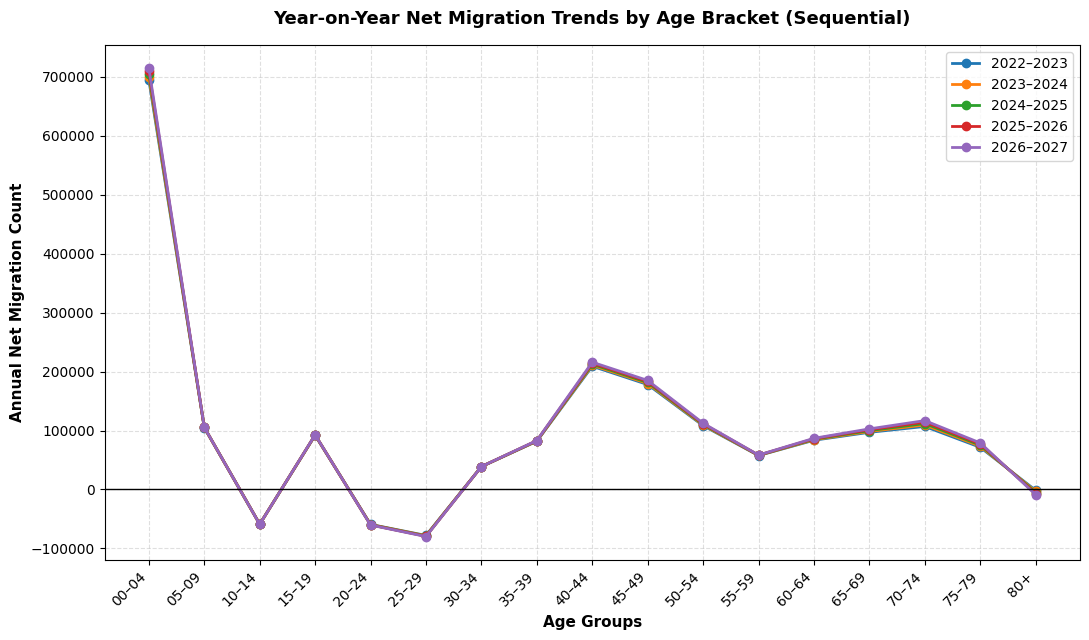

In [40]:
plt.figure(figsize=(11, 6.5))

for interval in intervals:
    y_values = [int(x.replace(',', '')) for x in df_yoy_mig.loc[df_yoy_mig["Age Group"] != "TOTAL", interval]]
    plt.plot(age_groups, y_values, marker='o', linewidth=2, label=interval)

plt.title('Year-on-Year Net Migration Trends (year on year)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Age Groups', fontsize=11, fontweight='bold')
plt.ylabel('Annual Net Migration Count', fontsize=11, fontweight='bold')

plt.axhline(0, color='black', linewidth=1, linestyle='-')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=10, loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('yoy_migration_lines.png', dpi=300)
plt.show()

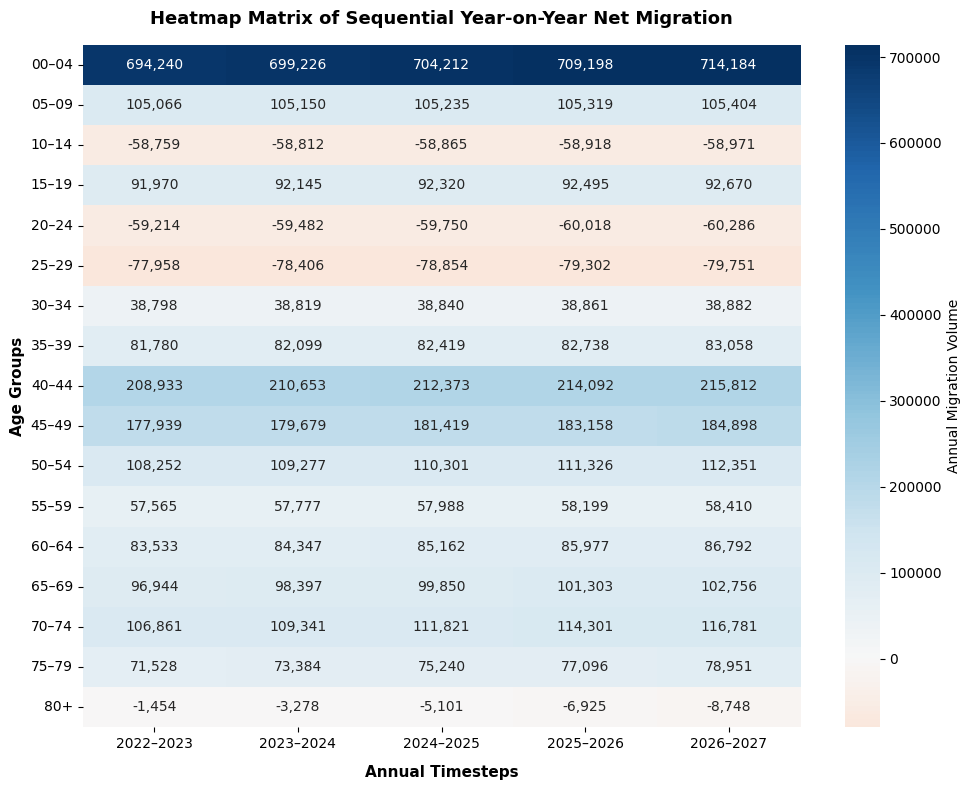

In [41]:
heatmap_data_yoy = []
for interval in intervals:
    column_numeric = [int(x.replace(',', '')) for x in df_yoy_mig.loc[df_yoy_mig["Age Group"] != "TOTAL", interval]]
    heatmap_data_yoy.append(column_numeric)

# Transpose matrix for clean alignment (Age Groups on Y-axis, Intervals on X-axis)
heatmap_matrix_yoy = np.array(heatmap_data_yoy).T

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_matrix_yoy, 
    annot=True, 
    fmt=",d", 
    cmap="RdBu", 
    center=0,
    xticklabels=intervals, 
    yticklabels=age_groups,
    cbar_kws={'label': 'Annual Migration Volume'}
)

plt.title('Heatmap Matrix of Sequential Year-on-Year Net Migration', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Annual Timesteps', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Age Groups', fontsize=11, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('yoy_migration_heatmap.png', dpi=300)
plt.show()